In [147]:
import numpy as np
import pandas as pd
import math
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [148]:
raw_data = pd.read_csv("diabetes.csv")

In [80]:
raw_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [81]:
label = np.array(raw_data.pop('Outcome'))
features = np.array(raw_data)

In [141]:
def PCA_numpy(X):
    x_new = np.copy(X)
    feature = x_new.shape[1]
    row = x_new.shape[0]
    x_mean = []
    for index in range(feature):
        _mean = X[:,index].mean()
        x_mean.append(_mean)
    # centring
    for index in range(feature):
        x_new[:,index] -= x_mean[index]
    x_t = np.transpose(x_new)
    x = x_new
    n = 1 / (row - 1)
    conv_matrix = np.dot(n,x_t)
    conv_matrix = np.dot(conv_matrix,x)
    
    
    eigenvalues, eigenvectors = np.linalg.eig(conv_matrix)
    
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    W = eigenvectors[:, :2]
    proj_of_x_on_w = np.dot(x,W)
    return proj_of_x_on_w
    

In [157]:
def LDA_numpy(x,y):
    pass

In [86]:
LDA_numpy()

In [87]:
# components = pd.DataFrame(min(raw_data, features) -1)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(features)

In [88]:
score = pca.score(features)
score

-34.024427099695885

In [153]:
x_pca

array([[-75.71465491,  35.95078264],
       [-82.3582676 , -28.90821322],
       [-74.63064344,  67.90649647],
       ...,
       [ 32.11319827,  -3.3766648 ],
       [-80.21449431,  14.18601977],
       [-81.30814972, -21.62149606]], shape=(768, 2))

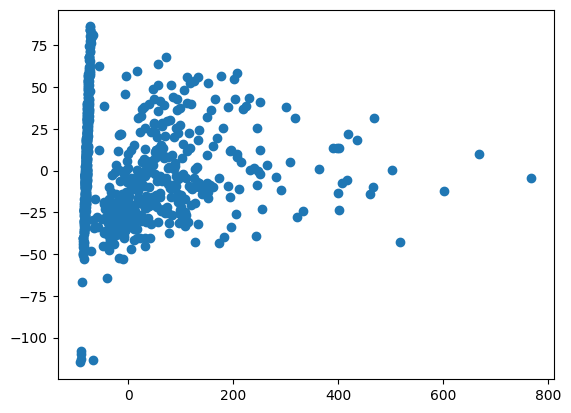

In [156]:
matrix = PCA_numpy(features)

matrix[:,0], matrix[:,1]
plt.scatter(matrix[:,0], matrix[:,1])

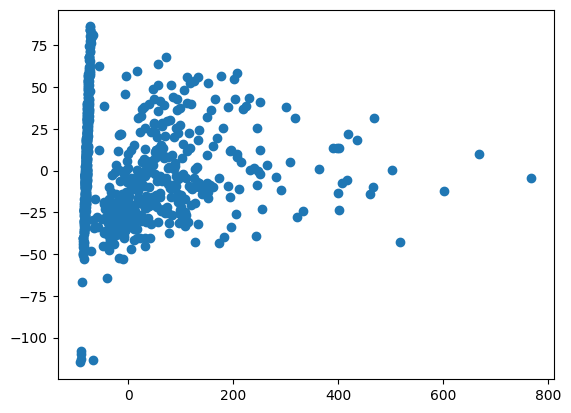

In [155]:
plt.scatter(x_pca[:,0], x_pca[:,1])

In [90]:
lda = LinearDiscriminantAnalysis()
x_lda = lda.fit_transform(features,label)

In [91]:
x_lda.shape

(768, 1)